In [ ]:
from typing import List, Tuple
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import optuna
import seaborn as sns
from utils import data

%cd ..
!git clone https://github.com/dodo47/GCDetection

In [3]:
class FrameDataset(Dataset):
    def __init__(self, df, transform=None):
        self.frames = np.stack(df.frame.values)
        self.labels = np.array(df.y, dtype=np.int64)
        self.transform =  transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if self.transform:
            ch1 = self.transform(self.frames[idx][0])
            ch2 = self.transform(self.frames[idx][1])
            img = np.stack([ch1, ch2])
        else:
            img = self.frames[idx].astype('float32') #/ 255

        return torch.tensor(img).float(), torch.tensor(int(self.labels[idx]))

/tmp/ipykernel_23456/2781098363.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_class_size, random_state=42))


<Axes: xlabel='y', ylabel='Count'>

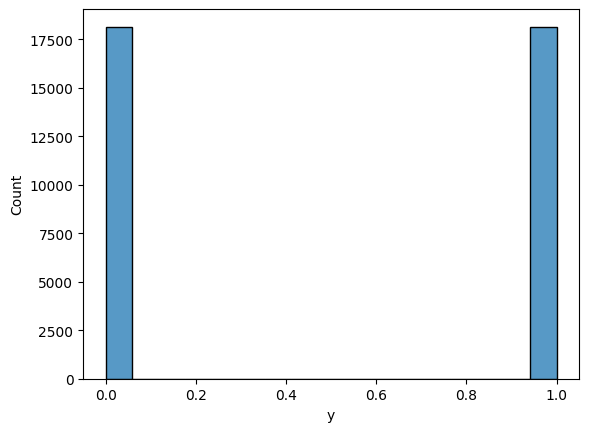

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

FCC, VCC = data.prepare_data()
all_frames = pd.concat((FCC, VCC), ignore_index=True)
all_frames = all_frames[~all_frames.frame.apply(lambda x: np.isnan(x).any())]

min_class_size = all_frames['y'].value_counts().min()


balanced_all_frames = (
    all_frames.groupby('y', group_keys=False)
    .apply(lambda x: x.sample(min_class_size, random_state=42))
)


train_df = balanced_all_frames.sample(frac=0.7, random_state=42)
rest = balanced_all_frames.drop(train_df.index)
val_df = rest.sample(frac=1/3, random_state=42)
test_df = rest.drop(val_df.index)



train_ds = DataLoader(
    FrameDataset(train_df), 
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
val_ds = DataLoader(FrameDataset(val_df), batch_size=64, shuffle=False)
test_ds = DataLoader(FrameDataset(test_df), batch_size=64, shuffle=False)

sns.histplot(balanced_all_frames["y"])

In [ ]:
class ConvGPBase(nn.Module):
    """Base class for Convolutional GP layers."""
    
    def __init__(self, device, in_channels, out_channels, kernel_size, 
                 M, padding=0, stride=1, log_s=0.5413, log_ls=0.5413, name=None):
        super().__init__()
        self.k = kernel_size
        self.out_channels = out_channels
        self.P = in_channels * kernel_size * kernel_size
        self.M = M
        self.padding = padding
        self.stride = stride
        self.device = device
        self.name = name
        
        # Inducing points Z (M, P)
        self.Z = nn.Parameter(torch.randn(M, self.P) * 0.1)
        
        # Kernel hyperparameters
        self.log_s = nn.Parameter(torch.log(torch.tensor(log_s)))
        self.log_ls = nn.Parameter(torch.log(torch.tensor(log_ls)))
    
    @property
    def sigma(self):
        return F.softplus(self.log_s)
    
    @property
    def lengthscale(self):
        return F.softplus(self.log_ls)
    
    def _rbf(self, x1, x2, s, ls):
        """RBF kernel with automatic broadcasting."""
        if x1.dim() == 3 and x2.dim() == 2:
            x2 = x2.unsqueeze(0)
        
        dist_sq = torch.cdist(x1, x2, p=2)**2
        return (s**2) * torch.exp(-dist_sq / (2 * (ls**2)))
    
    def initialize_inducing_kmeans(self, patches: torch.Tensor):
        """Initialize Z using k-means on patches (as per paper)."""
        patches_np = patches.detach().cpu().numpy()
        n_samples = min(patches_np.shape[0], self.M * 10)
        
        if n_samples < self.M:
            indices = np.random.choice(patches_np.shape[0], self.M, replace=True)
            self.Z.data.copy_(torch.from_numpy(patches_np[indices]).to(self.device))
        else:
            indices = np.random.choice(patches_np.shape[0], n_samples, replace=False)
            kmeans = KMeans(n_clusters=self.M, random_state=42, n_init=10)
            kmeans.fit(patches_np[indices])
            self.Z.data.copy_(torch.from_numpy(kmeans.cluster_centers_).to(self.device))


# ============================================================================
# EXTRACTOR LAYER
# ============================================================================

class ExtractorConvGP(ConvGPBase):
    """Convolutional GP layer for feature extraction (layers 1 to L-1)."""
    
    def __init__(self, device, in_channels, out_channels, kernel_size, M,
                 padding=0, stride=1, log_s=0.5413, log_ls=0.5413, name=None):
        super().__init__(device, in_channels, out_channels, kernel_size, M,
                        padding, stride, log_s, log_ls, name)
        
        # Inducing responses (M, out_channels)
        self.m = nn.Parameter(torch.randn(M, out_channels))
        
        # Variational covariance (M, M)
        self.L_S_raw = nn.Parameter(torch.eye(M))
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        N, C, H, W = x.shape
        s, ls = self.sigma, self.lengthscale
        
        # Extract patches: (N, C, H, W) -> (N, L, P)
        patches = F.unfold(x, kernel_size=self.k, padding=self.padding, 
                          stride=self.stride).transpose(1, 2)
        L = patches.shape[1]
        
        # Kernel matrices
        K_zz = self._rbf(self.Z, self.Z, s, ls) + 1e-5 * torch.eye(self.M, device=self.device)
        K_xz = self._rbf(patches, self.Z.unsqueeze(0), s, ls)  # (N, L, M)
        
        # Cholesky decomposition
        L_z = torch.linalg.cholesky(K_zz)
        A = torch.cholesky_solve(K_xz.transpose(1, 2), L_z).transpose(1, 2)
        
        # Predictive mean
        mean = torch.matmul(A, self.m)  # (N, L, out_channels)
        
        # Predictive variance
        L_S = torch.tril(self.L_S_raw)
        S = L_S @ L_S.T
        K_diff = K_zz - S
        term2 = torch.sum(torch.matmul(A, K_diff) * A, dim=-1, keepdim=True)
        var = (s**2) - term2
        var = var.clamp(min=1e-6)
        
        # Monte Carlo sampling (doubly stochastic)
        eps = torch.randn_like(mean)
        sample = mean + eps * torch.sqrt(var)
        
        # Reshape to image
        h_out = (H + 2 * self.padding - self.k) // self.stride + 1
        w_out = (W + 2 * self.padding - self.k) // self.stride + 1
        return sample.transpose(1, 2).view(N, self.out_channels, h_out, w_out)
    
    def kl_divergence(self) -> torch.Tensor:
        """Compute KL divergence KL(q(u)||p(u)) with correct GP prior N(0, K_zz)."""
        s, ls = self.sigma, self.lengthscale
        K_zz = self._rbf(self.Z, self.Z, s, ls) + 1e-5 * torch.eye(self.M, device=self.device)
        L_z = torch.linalg.cholesky(K_zz)
        L_S = torch.tril(self.L_S_raw)  # (M, M)
        m = self.m  # (M, out_channels)

        # tr(K_zz^{-1} S) = ||L_z^{-1} L_S||_F^2  (scaled by out_channels)
        alpha = torch.linalg.solve_triangular(L_z, L_S, upper=False)
        trace_term = self.out_channels * torch.sum(alpha ** 2)

        # m^T K_zz^{-1} m = ||L_z^{-1} m||_F^2
        beta_m = torch.linalg.solve_triangular(L_z, m, upper=False)
        mu_term = torch.sum(beta_m ** 2)

        M_dim = self.M * self.out_channels

        # log det(K_zz) - log det(S)
        log_det_Kzz = 2.0 * torch.sum(torch.log(torch.diagonal(L_z).abs() + 1e-8))
        log_det_S   = 2.0 * torch.sum(torch.log(torch.diagonal(L_S).abs() + 1e-8))
        log_det_term = self.out_channels * (log_det_Kzz - log_det_S)

        kl = 0.5 * (trace_term + mu_term - M_dim + log_det_term)
        return kl


# ============================================================================
# CLASSIFIER LAYER
# ============================================================================

class ClassifierConvGP(ConvGPBase):
    """Final classification layer with weighted patch aggregation."""
    
    def __init__(self, device, in_channels, in_shape, out_channels, kernel_size, M,
                 padding=0, stride=1, log_s=0.5413, log_ls=0.5413, name=None):
        super().__init__(device, in_channels, out_channels, kernel_size, M,
                        padding, stride, log_s, log_ls, name)
        
        h_in, w_in = in_shape
        h_out = (h_in + 2 * padding - kernel_size) // stride + 1
        w_out = (w_in + 2 * padding - kernel_size) // stride + 1
        self.L = h_out * w_out
        
        # Inducing responses (out_channels, M, 1)
        self.m = nn.Parameter(torch.randn(out_channels, M, 1))
        
        # Variational covariance (out_channels, M, M)
        self.L_S_raw = nn.Parameter(torch.eye(M).unsqueeze(0).repeat(out_channels, 1, 1))
        
        # Patch weights for aggregation
        self.w_logits = nn.Parameter(torch.randn(self.L))
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        N, C, H, W = x.shape
        s, ls = self.sigma, self.lengthscale
        
        # Extract patches
        patches = F.unfold(x, kernel_size=self.k, padding=self.padding,
                          stride=self.stride).transpose(1, 2)  # (N, L, P)
        
        # Kernel matrices
        K_zz = self._rbf(self.Z, self.Z, s, ls) + 1e-5 * torch.eye(self.M, device=self.device)
        K_xz = self._rbf(patches, self.Z, s, ls)  # (N, L, M)
        
        # Weight patches
        w = F.softmax(self.w_logits, dim=0)  # (L,)
        kw_xz = torch.einsum('l,nlm->nm', w, K_xz)  # (N, M)
        
        # Cholesky solve
        L_z = torch.linalg.cholesky(K_zz)
        v = torch.linalg.solve_triangular(L_z, kw_xz.T, upper=False)  # (M, N)
        
        # Predictive mean
        v_m = torch.linalg.solve_triangular(L_z.unsqueeze(0), self.m, upper=False)
        mean = torch.matmul(v_m.transpose(1, 2), v).squeeze(-2).T  # (N, out_channels)
        
        # Predictive variance
        term_std = torch.sum(v**2, dim=0, keepdim=True).T  # (N, 1)
        L_S = torch.tril(self.L_S_raw)
        v_S = torch.matmul(L_S.transpose(-1, -2), v.unsqueeze(0))
        term_S = torch.sum(v_S**2, dim=1).T  # (N, out_channels)
        var = (s**2 - term_std + term_S).clamp(min=1e-6)
        
        return mean, var
    
    def kl_divergence(self) -> torch.Tensor:
        """Compute KL divergence KL(q(u)||p(u)) with correct GP prior N(0, K_zz)."""
        s, ls = self.sigma, self.lengthscale
        K_zz = self._rbf(self.Z, self.Z, s, ls) + 1e-5 * torch.eye(self.M, device=self.device)
        L_z = torch.linalg.cholesky(K_zz)
        L_S = torch.tril(self.L_S_raw)  # (out_channels, M, M)
        m = self.m  # (out_channels, M, 1)

        # Broadcast L_z across output channels
        L_z_exp = L_z.unsqueeze(0)  # (1, M, M)

        # tr(K_zz^{-1} S_c) = ||L_z^{-1} L_S_c||_F^2, summed over channels
        alpha = torch.linalg.solve_triangular(L_z_exp, L_S, upper=False)  # (C, M, M)
        trace_term = torch.sum(alpha ** 2)

        # m_c^T K_zz^{-1} m_c = ||L_z^{-1} m_c||^2, summed over channels
        beta_m = torch.linalg.solve_triangular(L_z_exp, m, upper=False)  # (C, M, 1)
        mu_term = torch.sum(beta_m ** 2)

        M_dim = self.M * self.out_channels

        # log det(K_zz)*C - sum_c log det(S_c)
        log_det_Kzz = 2.0 * torch.sum(torch.log(torch.diagonal(L_z).abs() + 1e-8))
        diagonals = torch.diagonal(L_S, dim1=-2, dim2=-1)
        log_det_S  = 2.0 * torch.sum(torch.log(diagonals.abs() + 1e-8))
        log_det_term = self.out_channels * log_det_Kzz - log_det_S

        kl = 0.5 * (trace_term + mu_term - M_dim + log_det_term)
        return kl

In [ ]:
class DeepCGP(nn.Module):
    """Deep Convolutional Gaussian Process model."""
    
    def __init__(self, layers: List[nn.Module]):
        super().__init__()
        self.layers = nn.ModuleList(layers)
        self.device = layers[0].device
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Forward pass through all layers."""
        for i, layer in enumerate(self.layers):
            if isinstance(layer, ClassifierConvGP):
                return layer(x)  # Returns (mean, var)
            else:
                x = layer(x)  # Returns sampled features
        
        # Fallback if no classifier layer
        return x, torch.ones_like(x) * 0.1
    
    def kl_divergence(self) -> torch.Tensor:
        """Sum KL divergence across all layers."""
        total_kl = 0
        for layer in self.layers:
            total_kl += layer.kl_divergence()
        return total_kl
    
    @torch.no_grad()
    def initialize_inducing_points(self, dataloader: DataLoader):
        """Initialize inducing points using k-means on patches (paper method)."""
        self.eval()
        x, _ = next(iter(dataloader))
        x = x.to(self.device)
        
        current_input = x
        
        for i, layer in enumerate(self.layers):
            # Extract patches
            patches = F.unfold(current_input, kernel_size=layer.k,
                            padding=layer.padding, stride=layer.stride)
            patches = patches.transpose(1, 2).reshape(-1, layer.P)
            
            # Initialize Z with k-means
            layer.initialize_inducing_kmeans(patches)
            
            # Get next layer input (deterministic mean)
            if isinstance(layer, ClassifierConvGP):
                break
            
            # Run forward to get output for next layer initialization
            s, ls = layer.sigma, layer.lengthscale
            patches_reshaped = patches.view(x.shape[0], -1, layer.P)
            K_zz = layer._rbf(layer.Z, layer.Z, s, ls) + 1e-5 * torch.eye(layer.M, device=self.device)
            K_xz = layer._rbf(patches_reshaped, layer.Z.unsqueeze(0), s, ls)
            L_z = torch.linalg.cholesky(K_zz)
            A = torch.cholesky_solve(K_xz.transpose(1, 2), L_z).transpose(1, 2)
            mean = torch.matmul(A, layer.m)
            
            # Update current_input shape for next layer
            h_out = (current_input.shape[2] + 2 * layer.padding - layer.k) // layer.stride + 1
            w_out = (current_input.shape[3] + 2 * layer.padding - layer.k) // layer.stride + 1
            current_input = mean.transpose(1, 2).view(x.shape[0], layer.out_channels, h_out, w_out)


def elbo_loss(model: DeepCGP, x: torch.Tensor, y: torch.Tensor,
              num_samples: int = 10, beta: float = 1.0,
              dataset_size: int = 1000) -> Tuple[torch.Tensor, dict]:
    """Compute ELBO loss with Monte Carlo sampling."""
    mean, var = model(x)
    
    # Monte Carlo sampling (doubly stochastic)
    eps = torch.randn((num_samples, *mean.shape), device=x.device)
    f_samples = mean.unsqueeze(0) + eps * torch.sqrt(var.unsqueeze(0))
    f_samples_flat = f_samples.reshape(-1, f_samples.shape[-1])
    
    # Negative log likelihood
    log_prob = F.log_softmax(f_samples_flat, dim=-1)
    y_expanded = y.repeat(num_samples).long()
    nll = F.nll_loss(log_prob, y_expanded, reduction='mean')
    
    # KL divergence
    kl_term = model.kl_divergence() / dataset_size
    
    # Metrics on predictive mean
    with torch.no_grad():
        prob_mean = F.softmax(mean, dim=-1)
        accuracy = (prob_mean.argmax(dim=1) == y).float().mean()
    
    loss = nll + beta * kl_term
    
    metrics = {
        'loss': loss.item(),
        'nll': nll.item(),
        'kl': kl_term.item(),
        'accuracy': accuracy.item()
    }
    
    return loss, metrics

In [ ]:
def train_epoch(model: DeepCGP, dataloader: DataLoader, optimizer: torch.optim.Optimizer,
                device: torch.device, epoch: int, beta: float = 1.0,
                dataset_size: int = 1000, num_samples: int = 10,
                warmup_epochs: int = 20) -> dict:
    """Train for one epoch. beta is annealed from 0 → beta over warmup_epochs."""
    model.train()
    
    effective_beta = beta * min(1.0, (epoch + 1) / max(1, warmup_epochs))
    total_metrics = {'loss': 0.0, 'nll': 0.0, 'kl': 0.0, 'accuracy': 0.0}
    n_batches = 0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss, metrics = elbo_loss(model, x, y, num_samples, effective_beta, dataset_size)
        loss.backward()
        optimizer.step()
        
        for key in total_metrics:
            total_metrics[key] += metrics[key]
        n_batches += 1
    
    for key in total_metrics:
        total_metrics[key] /= n_batches
    
    return total_metrics


def validate(model: DeepCGP, dataloader: DataLoader, device: torch.device,
             num_samples: int = 10) -> dict:
    """Validate model."""
    model.eval()
    total_metrics = {'loss': 0.0, 'nll': 0.0, 'accuracy': 0.0}
    n_batches = 0
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            _, metrics = elbo_loss(model, x, y, num_samples, beta=0.0, dataset_size=1)
            
            for key in total_metrics:
                total_metrics[key] += metrics[key]
            n_batches += 1
    
    for key in total_metrics:
        total_metrics[key] /= n_batches
    
    return total_metrics

In [ ]:
# ============================================================================
# OPTUNA STUDY
# ============================================================================

def create_model(trial: optuna.Trial, device: torch.device, 
                 input_shape: Tuple[int, int], in_channels: int = 2,
                 n_classes: int = 2) -> DeepCGP:
    """Create model with hyperparameters from Optuna trial."""
    
    # Hyperparameters to optimize
    M = trial.suggest_categorical('M', [128, 256, 384, 512])
    kernel_size = trial.suggest_categorical('kernel_size', [3, 5])
    out_channels = trial.suggest_categorical('out_channels', [8, 16, 32])
    log_s = trial.suggest_float('log_s', -1.0, 1.0)
    log_ls = trial.suggest_float('log_ls', -1.0, 1.0)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    
    # Calculate padding
    padding = kernel_size // 2
    stride = 1
    
    # Extractor layer
    extractor = ExtractorConvGP(
        device=device,
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=kernel_size,
        M=M,
        padding=padding,
        stride=stride,
        log_s=np.exp(log_s),
        log_ls=np.exp(log_ls),
        name='extractor'
    )
    
    # Calculate extractor output shape
    h_in, w_in = input_shape
    h_out = (h_in + 2 * padding - kernel_size) // stride + 1
    w_out = (w_in + 2 * padding - kernel_size) // stride + 1
    
    # Classifier layer - use calculated output shape
    classifier = ClassifierConvGP(
        device=device,
        in_channels=out_channels,
        in_shape=(h_out, w_out),
        out_channels=n_classes,
        kernel_size=kernel_size,
        M=M,
        padding=padding,
        stride=stride,
        log_s=np.exp(log_s),
        log_ls=np.exp(log_ls),
        name='classifier'
    )
    
    model = DeepCGP([extractor, classifier]).to(device)
    model.learning_rate = learning_rate
    
    return model


def objective(trial: optuna.Trial, train_df, val_df, device: torch.device,
              input_shape: Tuple[int, int], n_epochs: int = 10,
              batch_size: int = 64, in_channels: int = 2, n_classes: int = 2) -> float:
    """Optuna objective function."""
    
    # Create dataloaders
    train_ds = DataLoader(FrameDataset(train_df), batch_size=batch_size, 
                         shuffle=True, num_workers=0, pin_memory=True)
    val_ds = DataLoader(FrameDataset(val_df), batch_size=batch_size, 
                       shuffle=False, num_workers=0)
    
    # Create model
    model = create_model(trial, device, input_shape, in_channels, n_classes)
    
    # Initialize inducing points with k-means
    model.initialize_inducing_points(train_ds)
    
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=model.learning_rate)
    
    # Learning rate scheduler (as per paper: multiply by 0.1 every N steps)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=n_epochs//3, gamma=0.1)
    
    # Training loop
    best_val_acc = 0
    dataset_size = len(train_df)
    
    for epoch in range(n_epochs):
        train_metrics = train_epoch(model, train_ds, optimizer, device, 
                                   epoch, beta=1.0, dataset_size=dataset_size)
        val_metrics = validate(model, val_ds, device)
        
        scheduler.step()
        
        if val_metrics['accuracy'] > best_val_acc:
            best_val_acc = val_metrics['accuracy']
    
    # Report best validation accuracy to Optuna
    trial.report(best_val_acc, n_epochs - 1)
    
    # Handle pruning
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    
    return best_val_acc


def run_optuna_study(train_df, val_df, device: torch.device,
                     input_shape: Tuple[int, int] = (28, 28),
                     n_trials: int = 20, n_epochs: int = 10,
                     in_channels: int = 2, n_classes: int = 2) -> optuna.Study:
    """Run complete Optuna optimization study."""
    
    study = optuna.create_study(
        direction='maximize',
        study_name='deep_cgp_optimization',
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
    )
    
    study.optimize(
        lambda trial: objective(trial, train_df, val_df, device, input_shape,
                               n_epochs, in_channels=in_channels, n_classes=n_classes),
        n_trials=n_trials,
        timeout=3600 * 6
    )
    
    print(f"Best trial: {study.best_trial.number}")
    print(f"Best validation accuracy: {study.best_value:.4f}")
    print(f"Best hyperparameters: {study.best_params}")
    
    return study


def create_best_model(study: optuna.Study, device: torch.device,
                      input_shape: Tuple[int, int], in_channels: int = 2,
                      n_classes: int = 2) -> DeepCGP:
    """Create model with best hyperparameters from study."""
    
    # Create a dummy trial with best params
    class DummyTrial:
        def suggest_categorical(self, name, choices):
            return study.best_params[name]
        def suggest_float(self, name, low, high, log=False):
            return study.best_params[name]
    
    return create_model(DummyTrial(), device, input_shape, in_channels, n_classes)

In [9]:
# Run optimization
study = run_optuna_study(
    train_df=train_df,
    val_df=val_df,
    device=device,
    input_shape=(20, 20),
    n_trials=20,
    n_epochs=10
)

# Create best model
best_model = create_best_model(study, device, (20, 20))
best_model.initialize_inducing_points(train_ds)

# Train final model
optimizer = torch.optim.Adam(best_model.parameters(), lr=study.best_params['learning_rate'])
for epoch in range(50):
    metrics = train_epoch(best_model, train_ds, optimizer, device, epoch)
    print(f"Epoch {epoch}: {metrics}")

[I 2026-03-04 16:58:41,184] A new study created in memory with name: deep_cgp_optimization
[I 2026-03-04 17:00:48,152] Trial 0 finished with value: 0.5110125855395669 and parameters: {'M': 128, 'kernel_size': 5, 'out_channels': 32, 'log_s': -0.824974913266117, 'log_ls': -0.6096995885642578, 'learning_rate': 0.00011007597599857163}. Best is trial 0 with value: 0.5110125855395669.
[I 2026-03-04 17:04:00,606] Trial 1 finished with value: 0.5110125855395669 and parameters: {'M': 384, 'kernel_size': 5, 'out_channels': 8, 'log_s': 0.31147582406844565, 'log_ls': -0.904216423069726, 'learning_rate': 0.00041037421712742414}. Best is trial 0 with value: 0.5110125855395669.
[I 2026-03-04 17:05:42,759] Trial 2 finished with value: 0.8642138640085856 and parameters: {'M': 128, 'kernel_size': 3, 'out_channels': 16, 'log_s': -0.5028522800999853, 'log_ls': 0.6019914127482757, 'learning_rate': 0.0014480398708616212}. Best is trial 2 with value: 0.8642138640085856.
[I 2026-03-04 17:10:32,675] Trial 3 fi

Best trial: 13
Best validation accuracy: 0.9202
Best hyperparameters: {'M': 256, 'kernel_size': 3, 'out_channels': 16, 'log_s': 0.1336887775845045, 'log_ls': 0.970640650253893, 'learning_rate': 0.009981737528837988}
Epoch 0: {'loss': 38.03112102573242, 'nll': 0.6141101497801105, 'kl': 748.3402194976807, 'accuracy': 0.6192682160804021}
Epoch 1: {'loss': 2.4030081701638113, 'nll': 0.3792435127642736, 'kl': 20.23764630418327, 'accuracy': 0.8556454145728644}
Epoch 2: {'loss': 1.379146865564375, 'nll': 0.34686004786036123, 'kl': 6.8819118516529025, 'accuracy': 0.8710217755943087}
Epoch 3: {'loss': 0.9682423289696774, 'nll': 0.3338452264872478, 'kl': 3.1719854405177896, 'accuracy': 0.8767666457286433}
Epoch 4: {'loss': 0.7745626258790194, 'nll': 0.32939138679049124, 'kl': 1.7806849557550708, 'accuracy': 0.8779705821269721}
Epoch 5: {'loss': 0.6720496125556715, 'nll': 0.32815639592295315, 'kl': 1.1463106753838121, 'accuracy': 0.8786903266331658}
Epoch 6: {'loss': 0.6106778912658068, 'nll': 0.

In [10]:
checkpoint = {
    'model_state_dict': best_model.state_dict(),
    'hyperparams': study.best_params
}

torch.save(checkpoint, "best_model.pth")

In [13]:
print(validate(best_model, test_ds, device), study.best_params, sep="\n")

{'loss': 0.3483514823673064, 'nll': 0.3483514823673064, 'accuracy': 0.8640870765635842}
{'M': 256, 'kernel_size': 3, 'out_channels': 16, 'log_s': 0.1336887775845045, 'log_ls': 0.970640650253893, 'learning_rate': 0.009981737528837988}
